In [23]:
import os
import sys

cwd = "/home/olafur/projects/RQM_prototype"
if cwd not in sys.path:
	sys.path.append("/home/olafur/projects/RQM_prototype")

import numpy as np
import pandas as pd
from pprint import pprint
import matplotlib.pyplot as plt

from pathlib import Path
import itertools as it

from prototype.magnetization import Magnetization
from prototype.lbfgs import lbfgs_minimizer

In [35]:
%matplotlib widget
plt.style.use("seaborn-v0_8-darkgrid")
fig_height = 7
plt.rcParams["figure.figsize"] = [2.5*fig_height, fig_height]
# plt.rcParams.update({'font.size': 16}) # Makes it easier to read on mobile devices

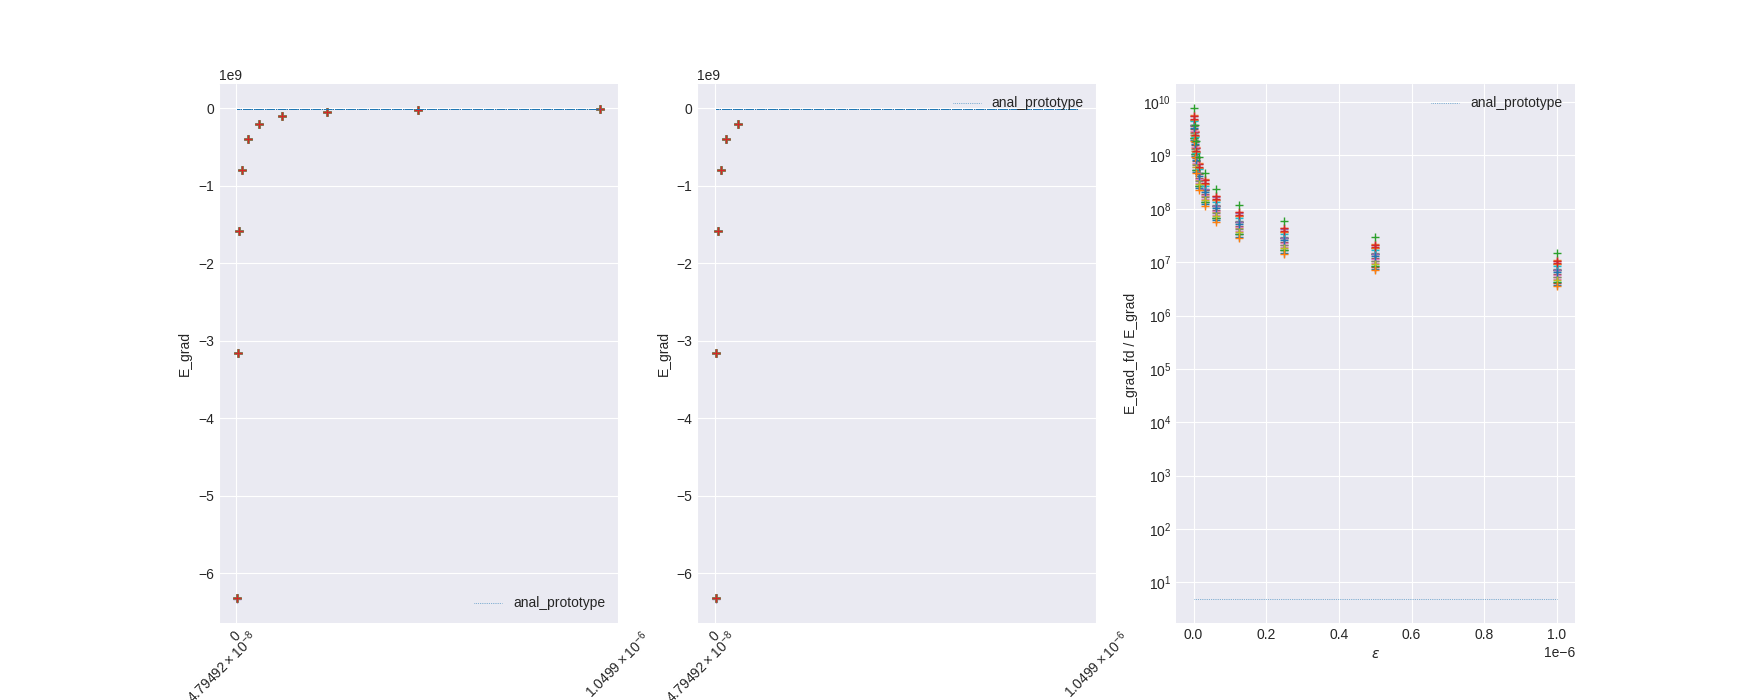

In [48]:
N = 2
N_coords = 3*N**3

# Standard random number generator
rng = np.random.default_rng()#seed=42)

# Create NxNxN grid
points = np.array([list(x) for x in it.product(range(N),repeat=3)])
points = np.array(points)

# Create random but normalized spins
spins_n = rng.random((N_coords,))
for ind_spin in range(N):
	t_norm = np.linalg.norm(spins_n[3*N:3*N+3])
	spins_n[3*N:3*N+3] = spins_n[3*N:3*N+3] / t_norm

mag = Magnetization(points=points,spins=spins_n, normalize_spins=True)

E_grad = mag.gradient()

N_epsilon = 10
E_grad_fd_array = np.zeros((N_coords,N_epsilon))
E_grad_fd = np.zeros((N_coords,))
epsilon_array = ((0.5)**np.arange(0,N_epsilon,1))*10**-6
for index_epsilon, iter_epsilon in enumerate(epsilon_array):
	for index_coord in range(N_coords):
		t_E_np1 = 0
		t_E_nm1 = 0

		t_spins = spins_n.copy()
		t_spins[index_coord] = t_spins[index_coord] + iter_epsilon
		mag.set_spins(t_spins)
		t_E_np1 = mag.energy()

		t_spins = spins_n.copy()
		t_spins[index_coord] = t_spins[index_coord] - iter_epsilon
		mag.set_spins(t_spins)
		t_E_np1 = mag.energy()

		E_grad_fd[index_coord] = (-0.5*t_E_nm1 + 0.5 + t_E_np1) / iter_epsilon
	E_grad_fd_array[:,index_epsilon] = E_grad_fd

fig, axes = plt.subplots(1,3,subplot_kw={})
for index_series in range(E_grad_fd_array.shape[0]):
	axes[0].plot(epsilon_array, E_grad_fd_array[index_series,:], ls="", marker="+")#, label=f"{index_series}")
axes[0].set_xlabel(r"$\varepsilon$")
axes[0].set_ylabel("E_grad")
axes[0].hlines(E_grad, xmin=np.min(epsilon_array),xmax=np.max(epsilon_array),ls='dotted',linewidth=0.5, label="anal_prototype")
axes[0].legend()
axes[0].tick_params("x",labelrotation=45)
axes[0].set_xscale('symlog')

for index_series in range(E_grad_fd_array.shape[0]):
	axes[1].plot(epsilon_array[4:], E_grad_fd_array[index_series,4:], ls="", marker="+")#, label=f"{index_series}")
axes[1].set_xlabel(r"$\varepsilon$")
axes[1].set_ylabel("E_grad")
axes[1].hlines(E_grad, xmin=np.min(epsilon_array),xmax=np.max(epsilon_array),ls='dotted',linewidth=0.5, label="anal_prototype")
axes[1].legend()
axes[1].tick_params("x",labelrotation=45)
axes[1].set_xscale('symlog')

for index_series in range(E_grad_fd_array.shape[0]):
	axes[2].plot(epsilon_array, E_grad_fd_array[index_series,:]/E_grad[index_series], ls="", marker="+")#, label=f"{index_series}")
axes[2].set_xlabel(r"$\varepsilon$")
axes[2].set_ylabel("E_grad_fd / E_grad")
axes[2].hlines(5, xmin=np.min(epsilon_array),xmax=np.max(epsilon_array),ls='dotted',linewidth=0.5, label="anal_prototype")
axes[2].legend()
axes[1].tick_params("x",labelrotation=45)
axes[2].set_yscale('symlog')

# Junk Drawer

In [ ]:
# N = 2

# # Standard random number generator
# rng = np.random.default_rng()#seed=42)

# # Create NxNxN grid
# points = np.array([list(x) for x in it.product(range(N),repeat=3)])
# points = np.array(points)

# # Create random but normalized spins
# spins_n = rng.random((3*N**3,))
# for ind_spin in range(N):
# 	t_norm = np.linalg.norm(spins_n[3*N:3*N+3])
# 	spins_n[3*N:3*N+3] = spins_n[3*N:3*N+3] / t_norm

# mag = Magnetization(points=points,spins=spins_n, normalize_spins=True)

# E_grad = mag.gradient()

# N_epsilon = 10
# E_grad_fd_array = np.zeros((3*N**3,N_epsilon))
# epsilon_array = ((0.5)**np.arange(0,N_epsilon,1))*10**-5
# t_E_nm1 = np.zeros((3*N**3,))
# t_E_np1 = np.zeros((3*N**3,))
# for index_epsilon, iter_epsilon in enumerate(epsilon_array):
# 	recip_epsilon = 1/iter_epsilon

# 	for ind_comp in range(t_E_nm1.shape[0]):
# 		t_spins = spins_n.copy()
# 		t_spins[ind_comp] = t_spins[ind_comp] - iter_epsilon
# 		mag.set_spins(t_spins)
# 		t_E_nm1[ind_comp] = mag.energy()

# 	for ind_comp in range(t_E_np1.shape[0]):
# 		t_spins = spins_n.copy()
# 		t_spins[ind_comp] = t_spins[ind_comp] + iter_epsilon
# 		mag.set_spins(t_spins)
# 		t_E_np1[ind_comp] = mag.energy()

# 	t_E_grad_fd = (-0.5 * t_E_nm1 + 0.5*t_E_np1)*recip_epsilon
# 	E_grad_fd_array[:,index_epsilon] = t_E_grad_fd

# fig, ax = plt.subplots()
# for index_series in range(E_grad_fd_array.shape[0]):
# 	ax.plot(epsilon_array, E_grad_fd_array[index_series,:], ls="", marker="+")#, label=f"{index_series}")
# ax.set_xlabel(r"$\varepsilon$")
# ax.set_ylabel("E_grad")
# ax.hlines(E_grad, xmin=np.min(epsilon_array),xmax=np.max(epsilon_array),ls='dotted',linewidth=0.5, label="anal_prototype")
# ax.legend()